# Dark & Background Removal

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import glob

from glide.common_components.utils import mask_average
from glide.common_components.utils import circular_mask
from glide.common_components import constants
import glide.science_data_processing.L1A as L1A
import glide.common_components.view_geometry as view_geometry
from glide.common_components.stars import get_beta_angle


In [42]:
# Generate masks
imager = 'NFI'
npix = constants.NPIX[imager]
half_npix = npix // 2
fov_radius = constants.MASK_L1A_FOV_R[imager]
full_fov_mask = circular_mask(npix, fov_radius)


## Load data and generate masks

In [43]:
# 1. Get filepaths dynamically (returns a sorted list for proper time order)
#file_paths = sorted(glob.glob(f"/data/L1A/CARRUTHERS_GCI-{imager}_L1A-DRK_*_v1.0.nc"))

file_paths = sorted(glob.glob(f"/data/L1A/CARRUTHERS_GCI-{imager}_L1A-DRK_202511[1-3][0-9]_v1.0.nc"))
print(file_paths)
# 2. Open datasets with lazy loading & minimal metadata schema (Blazing fast!)
# We assume the time dimension doesn't need complex concatenation alignment.
ds_all = xr.open_mfdataset(
    file_paths, 
    combine="nested", 
    concat_dim="time", 
    chunks={"time": 10},  # Lazy loading using Dask (adjust chunk size as needed)
    parallel=True         # Speeds up parsing metadata across cores
)

# 3. Access your L1A wrapper
l1a_all = L1A.L1A(ds_all)

# 4. Correct dimension names & vectorize
# Ensure dims match the actual variables in your dataset (e.g., 'y', 'x' or 'rows', 'cols')
#fov_mask_xr = xr.DataArray(full_fov_mask, dims=['y', 'x'])

# 5. Broadcast and compute means
# Expand dims over 'time' and perform a lazy reduction (avoids computing until explicitly asked)
#fov_mask_3d = fov_mask_xr.expand_dims({'time': ds_all.sizes['time']})
#fovs_ds = l1a_all.images.where(fov_mask_3d)

# Calculate mean and trigger the actual computation to memory at the very end
#avgs_ds = fovs_ds.mean(dim=['y', 'x']) / l1a_all.t_int
#avgs_ds = avgs_ds.compute() 


['/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251110_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251111_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251112_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251113_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251114_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251115_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251116_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251117_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251118_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251119_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251120_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251121_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251122_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251123_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251124_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251125_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_L1A-DRK_20251126_v1.0.nc', '/data/L1A/CARRUTHERS_GCI-NFI_

/tmp/ipykernel_620092/3240464327.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_all = xr.open_mfdataset(


In [49]:
sci_filepath = "/data/L1A/CARRUTHERS_GCI-NFI_L1A-SCI_20251113_v1.0.nc"

with xr.open_dataset(sci_filepath) as ds_sci:
    l1a_sci = L1A.L1A(ds_sci)

top_correction = np.load(f'products/COL_BIAS_{imager}_TOP.npy')
bottom_correction = np.load(f'products/COL_BIAS_{imager}_BOTTOM.npy')

print(fovs.shape)

In [ ]:
tg_dark_img = l1a_all.images[nearest_idx_pos] / l1a_all.n_frames[nearest_idx_pos]
m1_dark_img = l1a_all.images[nearest_idx_pos -1] / l1a_all.n_frames[nearest_idx_pos -1]
p1_dark_img = l1a_all.images[nearest_idx_pos +1] / l1a_all.n_frames[nearest_idx_pos +1]

top_col_biases = np.load(f'products/COL_BIAS_{imager}_TOP.npy')
bottom_col_biases = np.load(f'products/COL_BIAS_{imager}_BOTTOM.npy')

# subtract biases from all dark images
tg_dark_img[:half_npix, :] -= top_correction
tg_dark_img[half_npix:, :] -= bottom_correction
m1_dark_img[:half_npix, :] -= top_correction
m1_dark_img[half_npix:, :] -= bottom_correction
p1_dark_img[:half_npix, :] -= top_correction
p1_dark_img[half_npix:, :] -= bottom_correction

plt.imshow(tg_dark_img, vmax=np.percentile(tg_dark_img, 99), vmin=0)
plt.title(f"Dark Image Nearest Target Time\n{l1a_all.time[nearest_idx_pos]}")
plt.colorbar()
plt.show()


# --- 3. FIX: Robust N-Image Moving Average Section ---
idx = nearest_idx_pos
vmax_scale = np.percentile(tg_dark_img, 95) # Use the target dark image for scaling reference
n = 11
# Use clipping to ensure indices stay within array bounds (prevents IndexError/Negative wrapping)
start_idx = max(0, idx - n)
end_idx = min(len(l1a_all.images), idx + n + 1) # +1 makes it include 10 after

# Use explicit positional indexing so the time window includes both pre- and post-target images
time_dim = l1a_all.images[0]
n_ims = l1a_all.images[start_idx:end_idx].copy()
n_n_frames = l1a_all.n_frames[start_idx:end_idx].copy()

# Dynamically adapt to the actual size of the sliced frames array
n_ims_norm = n_ims / n_n_frames[:, np.newaxis, np.newaxis]

# Calculate mean along the time axis (axis=0)
avg20_dark_img = np.mean(n_ims_norm, axis=0)

# Subtract biases from the averaged image
avg20_dark_img[:half_npix, :] -= top_correction
avg20_dark_img[half_npix:, :] -= bottom_correction


# 1. Properly unpack the axes tuple (ax instead of axs)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 2. Use axis-specific methods (.imshow and .set_title) without overwriting 'ax'
im0 = ax[0].imshow(tg_dark_img, vmax=vmax_scale, vmin=0)
ax[0].set_title(f"Dark Image Nearest Target Time\n{l1a_all.time[nearest_idx_pos]}")

im1 = ax[1].imshow(avg20_dark_img, vmax=vmax_scale, vmin=0)
ax[1].set_title(f"Average of {n} Dark Images\n({n//2} Before, {n//2} After Target Time)")

# 3. Explicitly link the colorbar to one of the images so matplotlib knows where to draw it
fig.colorbar(im1, ax=ax, orientation='vertical')

plt.show()

ValueError: operands could not be broadcast together with shapes (512,1024) (1,512) (512,1024) 

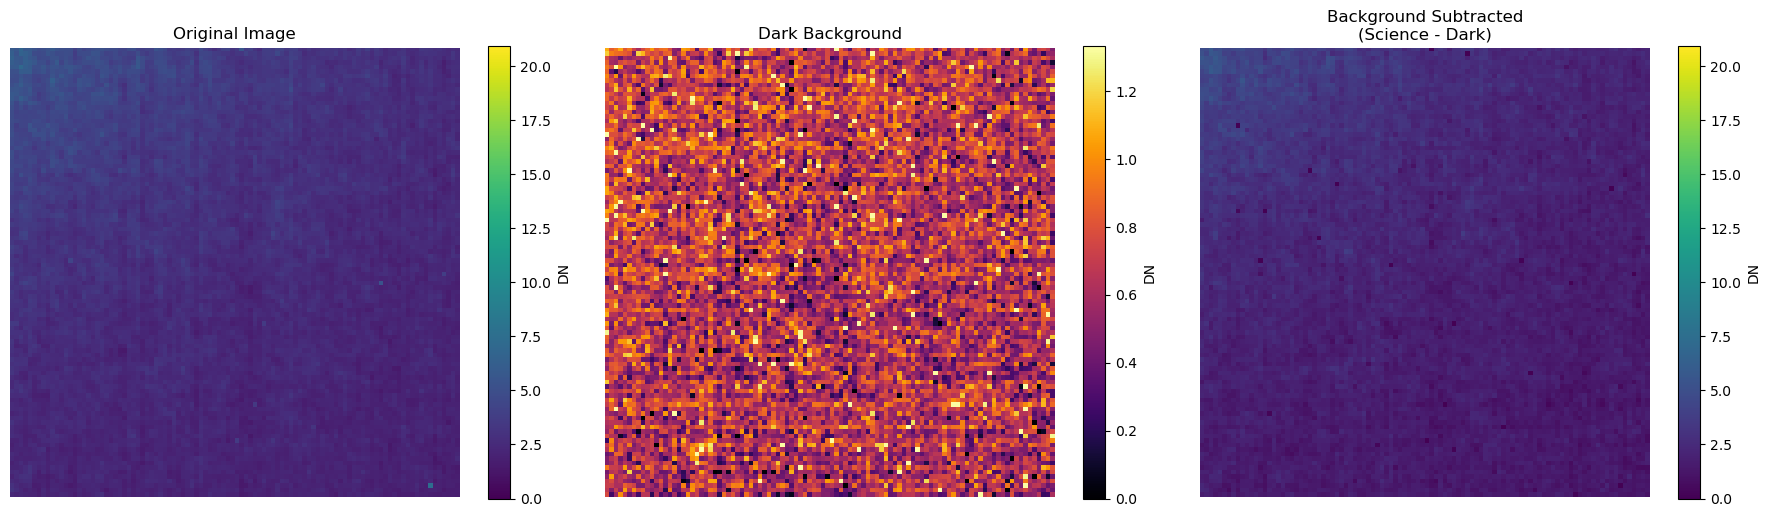

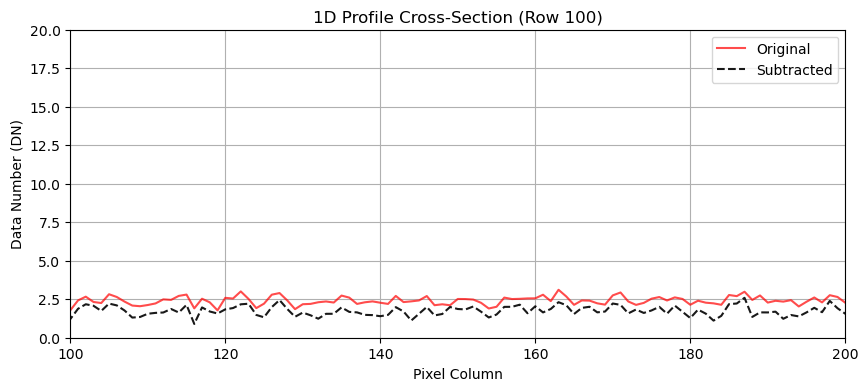

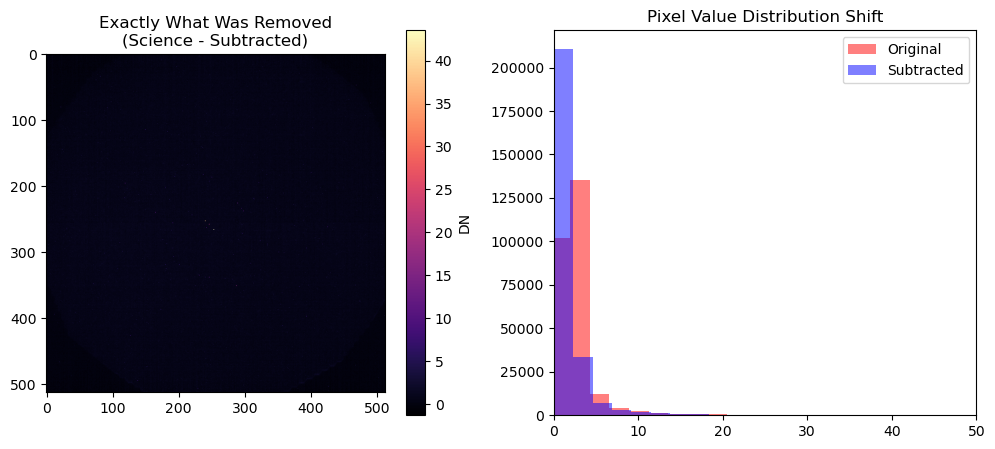

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm



# --- 1. Simulate your data (Replace these with your actual image arrays) ---
# Science image: peak 1200 DN
science_img = sci_img_norm.copy()

# Dark image: peak 2.5 DN
dark_img = avg20_dark_img.copy()

# --- 2. Perform Background Subtraction ---
# Clipping at 0 prevents negative pixel values (optional but recommended for science)
subtracted_img = np.clip(science_img - dark_img, 0, None)

# --- 3. Plot the Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sci_max = np.percentile(science_img, 99)  # Use 99th percentile to avoid outliers dominating the color scale
# Panel 1: Original Science Image (Linear scale up to 1200 DN)
im1 = axes[0].imshow(science_img[300:400,300:400], cmap='viridis', vmin=0, vmax=sci_max)
axes[0].set_title("Original Image")
fig.colorbar(im1, ax=axes[0], label='DN')

# Panel 2: Dark Image (Boosted/Clipped scale up to 2.5 DN so you can see it)
im2 = axes[1].imshow(dark_img[300:400,300:400], cmap='inferno', vmin=0, vmax=np.percentile(dark_img, 99))
axes[1].set_title("Dark Background")
fig.colorbar(im2, ax=axes[1], label='DN')

# Panel 3: Subtracted Result (Linear scale up to 1200 DN)
im3 = axes[2].imshow(subtracted_img[300:400,300:400], cmap='viridis', vmin=0, vmax=sci_max)
axes[2].set_title("Background Subtracted\n(Science - Dark)")
fig.colorbar(im3, ax=axes[2], label='DN')

# Clean up layout
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

# Choose a single row index that passes through your object (e.g., row 250)
row_idx = 100

plt.figure(figsize=(10, 4))
plt.plot(science_img[row_idx, :], label='Original', color='red', alpha=0.7)
plt.plot(subtracted_img[row_idx, :], label='Subtracted', color='black', linestyle='--', alpha=0.9)

plt.title(f"1D Profile Cross-Section (Row {row_idx})")
plt.xlabel("Pixel Column")
plt.ylabel("Data Number (DN)")

# ZOOM IN on the Y-axis to see the 2.5 DN difference clearly
plt.ylim(0, 20) 
plt.xlim(100, 200)
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Show exactly what was removed
im = axes[0].imshow(science_img - subtracted_img, cmap='magma')
axes[0].set_title("Exactly What Was Removed\n(Science - Subtracted)")
fig.colorbar(im, ax=axes[0], label='DN')

# Plot 2: Histogram showing the entire dataset shifting left by ~1-2 DN
axes[1].hist(science_img.flatten(), bins=100, alpha=0.5, label='Original', color='red')
axes[1].hist(subtracted_img.flatten(), bins=100, alpha=0.5, label='Subtracted', color='blue')
axes[1].set_title("Pixel Value Distribution Shift")
axes[1].set_xlim(0, 50) # Zoom in on the background noise floor
axes[1].legend()

plt.show()



In [48]:
import matplotlib.pyplot as plt
images = l1a_all.images

target_time = l1a_sci.time[l1a_sci.time.size // 2]
print(type(l1a_sci.time[0]))

dt_index = pd.DatetimeIndex(l1a_all.time)
target_dt = pd.Timestamp(target_time)

nearest_idx_pos = dt_index.get_indexer([target_dt], method='nearest')[0]
nearest_label = dt_index[nearest_idx_pos]

print(f"Target: {target_dt}")
print(f"Nearest: {nearest_label}")

nearest_dark_img = l1a_all.images[nearest_idx_pos]

# subtract
sci_img_norm = l1a_sci.images[0, :, :]/l1a_all.n_frames[0]
drk_img_norm = nearest_dark_img/l1a_all.n_frames[nearest_idx_pos]
subtracted_img = sci_img_norm - drk_img_norm

# Subtract voltage biases
top_col_biases = np.load(f'products/COL_BIAS_{imager}_TOP.npy')
bottom_col_biases = np.load(f'products/COL_BIAS_{imager}_BOTTOM.npy')
half_npix = constants.NPIX[imager] // 2
top_correction =  top_col_biases[np.newaxis, :]
bottom_correction =  bottom_col_biases[np.newaxis, :]
drk_img_norm[:half_npix, :] -= top_correction
drk_img_norm[half_npix:, :] -= bottom_correction

sci_max = np.percentile(sci_img_norm, 99)
sci_min = 0

subtracted_avg20_img = sci_img_norm - avg20_dark_img

fs= 4
fig, axs = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
axs[0,0].imshow(sci_img_norm,   vmin=sci_min, vmax=sci_max)
axs[0,0].set_title('Original Image')

axs[0,1].imshow(drk_img_norm,   vmin=0, vmax=np.percentile(drk_img_norm, 99))
axs[0,1].set_title('Dark Image')

axs[0,2].imshow(avg20_dark_img, vmin=0, vmax=1)
axs[0,2].set_title('Moving Average Dark Image')

axs[1,1].imshow(subtracted_img, vmin=sci_min, vmax=sci_max)
axs[1,1].set_title('Subtracted Original Dark Image')

axs[1,2].imshow(subtracted_avg20_img, vmin=sci_min, vmax=sci_max)
axs[1,2].set_title('Subtracted Moving Average Dark Image')

axs[1,0].axis('off')
plt.show()


<class 'numpy.datetime64'>
Target: 2025-11-13 14:55:45
Nearest: 2025-11-13 14:46:55


ValueError: operands could not be broadcast together with shapes (1024,1024) (512,512) 